#Assignment 1

- Data Preprocessing

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [1]:
from google.colab import files

# This will open a file selector to upload your CSV
uploaded = files.upload()

Saving Pakistan Largest Ecommerce Dataset.csv to Pakistan Largest Ecommerce Dataset.csv


In [11]:
# Load the CSV file (dataset)

df = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")
df.head()

/tmp/ipykernel_1226/450701716.py:3: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [14]:
# Remove unused columns
#sku: product code, too many unique values, not useful
#increment_id: just an order ID, no analytical value
#M-Y: redundant, we already have 'Year' and 'Month'
#FY: redundant with 'Year' column
#Working Date: redundant, we already have 'created_at'
#MV: unclear column, no business meaning
#sales_commission_code: not related to target variable grand_total
#Unnamed: 21 to 25: completely empty columns (100% null values)
df = df.drop(['sku', 'increment_id', 'M-Y', 'FY', 'Working Date',
              'MV', 'sales_commission_code',
              'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
              'Unnamed: 24', 'Unnamed: 25'], axis=1)  # axis=1 means we are dropping columns

print('Shape after removing unused columns:', df.shape)

Shape after removing unused columns: (1048575, 14)


In [16]:
# Handle Null values
# check how many null values each column has
df.isnull().sum()

,0
item_id,464051
status,464066
created_at,464051
price,464051
qty_ordered,464051
grand_total,464051
category_name_1,464215
discount_amount,464051
payment_method,464051
BI Status,464051


In [18]:
# numerical columns fill with mean (keeps the data distribution balanced)
df['price'] = df['price'].fillna(df['price'].mean())
df['grand_total'] = df['grand_total'].fillna(df['grand_total'].mean())

In [19]:
# these numerical columns get 0 because missing means none/unknown
df['item_id'] = df['item_id'].fillna(0)
df['qty_ordered'] = df['qty_ordered'].fillna(0)
df['discount_amount'] = df['discount_amount'].fillna(0)
df['Year'] = df['Year'].fillna(0)
df['Month'] = df['Month'].fillna(0)
df['Customer Since'] = df['Customer Since'].fillna(0)
df['Customer ID'] = df['Customer ID'].fillna(0)

In [20]:
# categorical columns, fill with Unknown so we don't lose the row
df['status'] = df['status'].fillna('Unknown')
df['created_at'] = df['created_at'].fillna('Unknown')
df['category_name_1'] = df['category_name_1'].fillna('Unknown')
df['payment_method'] = df['payment_method'].fillna('Unknown')
df['BI Status'] = df['BI Status'].fillna('Unknown')

In [21]:
# verify all nulls are gone and all values should show 0
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
price,0
qty_ordered,0
grand_total,0
category_name_1,0
discount_amount,0
payment_method,0
BI Status,0


In [22]:
# Handle duplicates
# check how many duplicate rows exist
df.duplicated().sum()

np.int64(464050)

In [23]:
# remove duplicate rows
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (584525, 14)


Categorical columns contain text which models cannot read. We used LabelEncoder to convert text into numbers.

In [27]:
# Handle Categorical Features
# LabelEncoder converts text labels into numbers so the model can understand them

le = LabelEncoder()

df['status'] = le.fit_transform(df['status'].astype(str))
df['created_at'] = le.fit_transform(df['created_at'].astype(str))
df['category_name_1'] = le.fit_transform(df['category_name_1'].astype(str))
df['payment_method'] = le.fit_transform(df['payment_method'].astype(str))
df['BI Status'] = le.fit_transform(df['BI Status'].astype(str))
df['Customer Since'] = le.fit_transform(df['Customer Since'].astype(str))

In [28]:
# verify
df.dtypes

,0
item_id,float64
status,int64
created_at,int64
price,float64
qty_ordered,float64
grand_total,float64
category_name_1,int64
discount_amount,float64
payment_method,int64
BI Status,int64


In [30]:
# Find correlations
# correlation tells us how strongly each feature is related to grand_total
corr = df.corr(numeric_only=True)['grand_total'].sort_values(ascending=False)
print(corr)

grand_total        1.000000
qty_ordered        0.753486
price              0.277607
discount_amount    0.104825
Customer ID        0.054044
Customer Since     0.049600
item_id            0.049265
category_name_1    0.044617
Year               0.012542
created_at         0.009951
Month             -0.020887
payment_method    -0.024492
status            -0.028874
BI Status         -0.046644
Name: grand_total, dtype: float64


In [31]:
# top 5 most important features aligned with grand_total
print('Top 5 Important Features:')
print(corr.drop('grand_total').head(5))

Top 5 Important Features:
qty_ordered        0.753486
price              0.277607
discount_amount    0.104825
Customer ID        0.054044
Customer Since     0.049600
Name: grand_total, dtype: float64


In [32]:
# redundant features very low correlation, not useful for prediction
print('Redundant Features (low correlation):')
print(corr.tail(5))

Redundant Features (low correlation):
created_at        0.009951
Month            -0.020887
payment_method   -0.024492
status           -0.028874
BI Status        -0.046644
Name: grand_total, dtype: float64


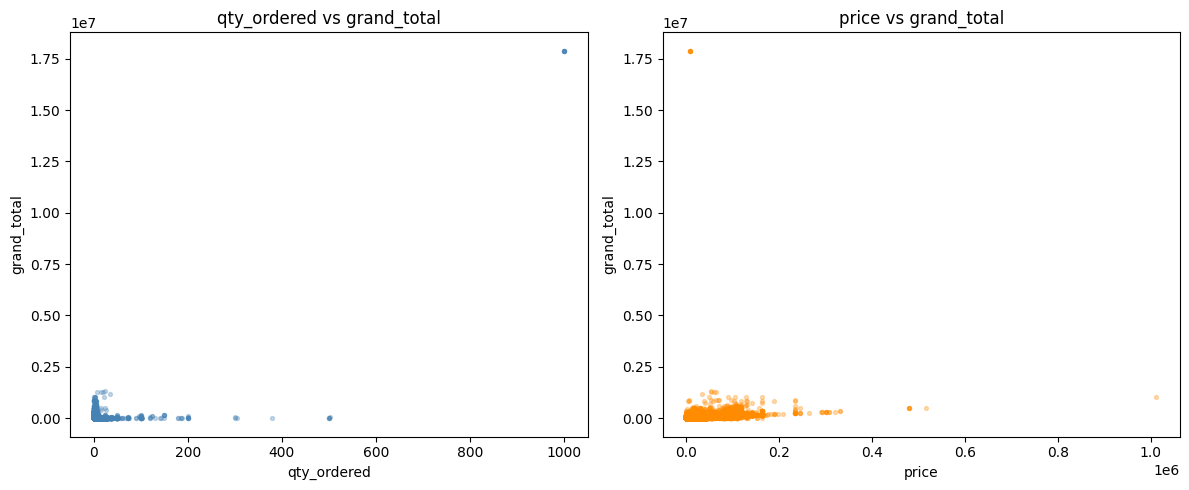

In [33]:
# scatter plot for top 2 important features qty_ordered and price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['qty_ordered'], df['grand_total'], alpha=0.3, color='steelblue', s=8)
axes[0].set_xlabel('qty_ordered')
axes[0].set_ylabel('grand_total')
axes[0].set_title('qty_ordered vs grand_total')

axes[1].scatter(df['price'], df['grand_total'], alpha=0.3, color='darkorange', s=8)
axes[1].set_xlabel('price')
axes[1].set_ylabel('grand_total')
axes[1].set_title('price vs grand_total')

plt.tight_layout()
plt.show()

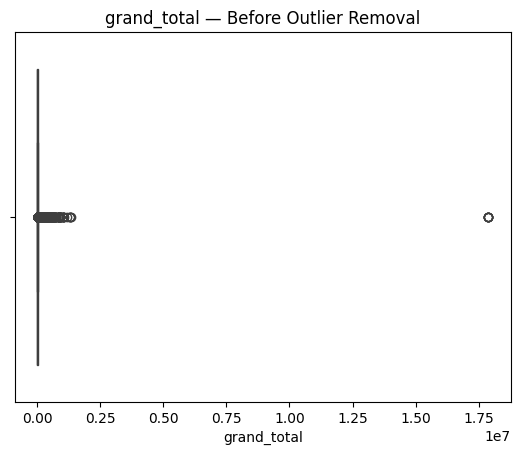

In [35]:
# boxplot to visualize outliers in grand_total
sns.boxplot(x=df['grand_total'])
plt.title('grand_total — Before Outlier Removal')
plt.show()

Outliers are extreme values that disturb our data. We used the IQR method to find and remove them.

In [36]:
# Handle Outliers
# using IQR method removes values that are too far from the normal range
# IQR = Q3 - Q1 (middle 50% of data)
# anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is an outlier

Q1 = df['grand_total'].quantile(0.25)
Q3 = df['grand_total'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('Lower bound:', lower)
print('Upper bound:', upper)

df = df[(df['grand_total'] >= lower) & (df['grand_total'] <= upper)]
print('Shape after removing outliers:', df.shape)

Lower bound: -8136.0
Upper bound: 16080.0
Shape after removing outliers: (507435, 14)


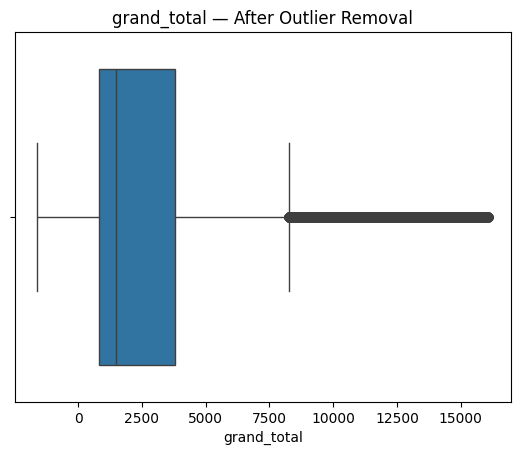

In [37]:
# boxplot after outlier removal it should look much cleaner now
sns.boxplot(x=df['grand_total'])
plt.title('grand_total — After Outlier Removal')
plt.show()

- Data Analytics

In [55]:
# best selling category
# mapping encoded numbers back to real category names
category_names = {0: 'Appliances', 1: 'Beauty & Grooming', 2: 'Books', 3: 'Computing',
                  4: 'Entertainment', 5: 'Health & Sports', 6: 'Home & Living',
                  7: 'Kids & Baby', 8: "Men's Fashion", 9: 'Mobiles & Tablets',
                  10: 'Others', 11: 'School & Education', 12: 'Soghaat',
                  13: 'Superstore', 14: 'Unknown', 15: "Women's Fashion", 16: "\\N"}

df['category_label'] = df['category_name_1'].map(category_names)

best_selling = df['category_label'].value_counts()
# remove Unknown and \N from results
best_selling = best_selling[~best_selling.index.isin(['Unknown', '\\N'])]
print('Best Selling Category:', best_selling.index[0], 'with', best_selling.iloc[0], 'orders')

Best Selling Category: Women's Fashion with 91019 orders


/tmp/ipykernel_1226/284561774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_selling.head(10).values, y=best_selling.head(10).index, palette='Blues_r')


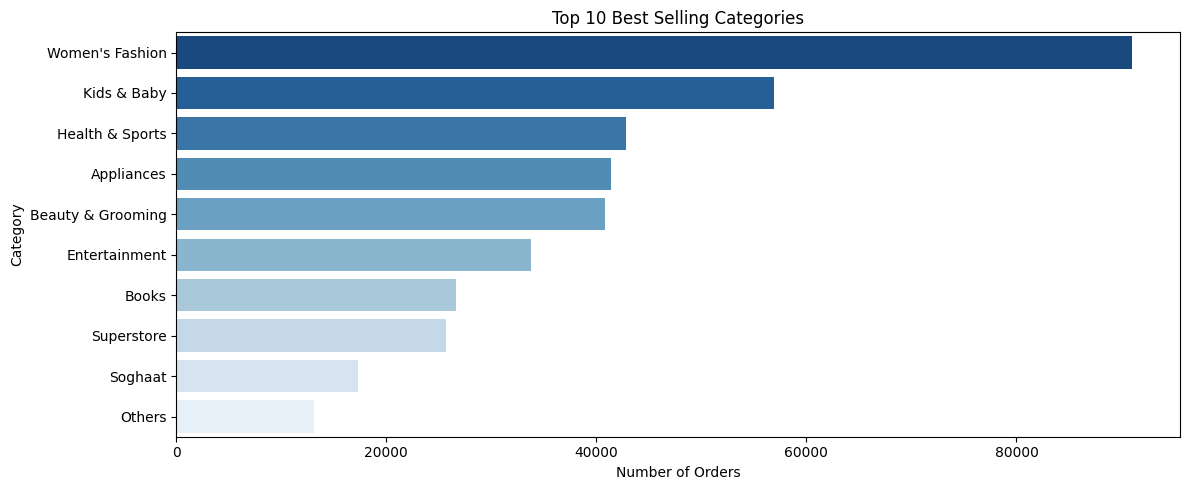

In [56]:
# bar chart with real category names
plt.figure(figsize=(12, 5))
sns.barplot(x=best_selling.head(10).values, y=best_selling.head(10).index, palette='Blues_r')
plt.title('Top 10 Best Selling Categories')
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

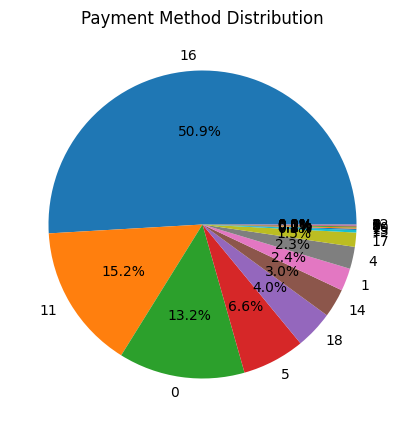

In [41]:
# Visualize payment method and order status frequency
# pie chart for payment method distribution

plt.figure(figsize=(8, 5))
df['payment_method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

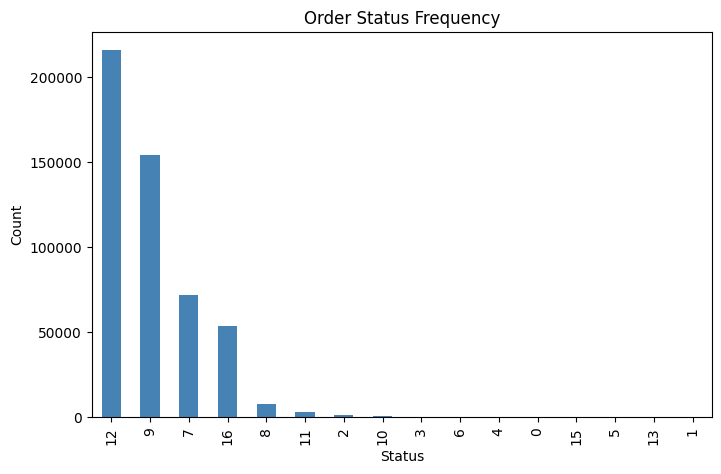

In [42]:
# bar chart for order status frequency
plt.figure(figsize=(8, 5))
df['status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Order Status Frequency')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

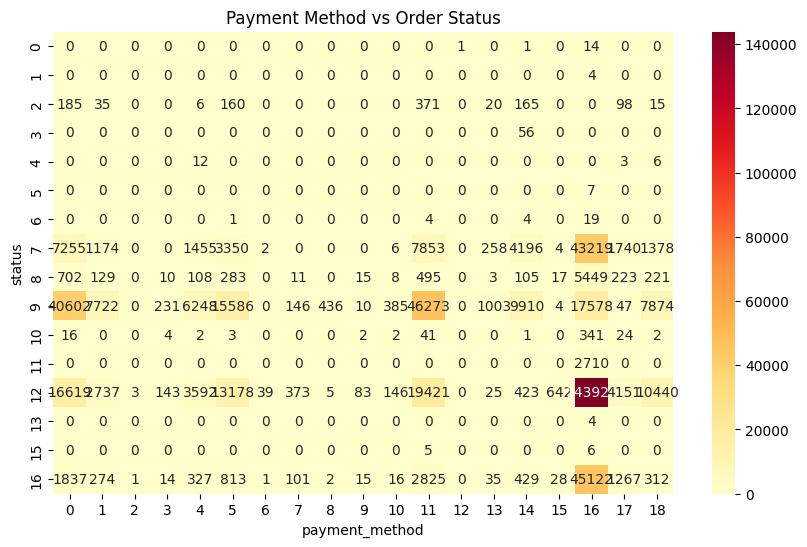

In [43]:
# Correlation between payment method and order status
# crosstab shows how often each payment method appears with each status
ct = pd.crosstab(df['status'], df['payment_method'])

# heatmap to visualize the correlation
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Payment Method vs Order Status')
plt.show()

In [44]:
# Correlation between order date and item category
# extract month from created_at (already encoded, so we use Month column directly)
monthly_cat = df.groupby(['Month', 'category_name_1'])['qty_ordered'].sum().reset_index()

In [45]:
# top 5 categories only to keep the chart readable
top5 = df['category_name_1'].value_counts().head(5).index
df_top = monthly_cat[monthly_cat['category_name_1'].isin(top5)]

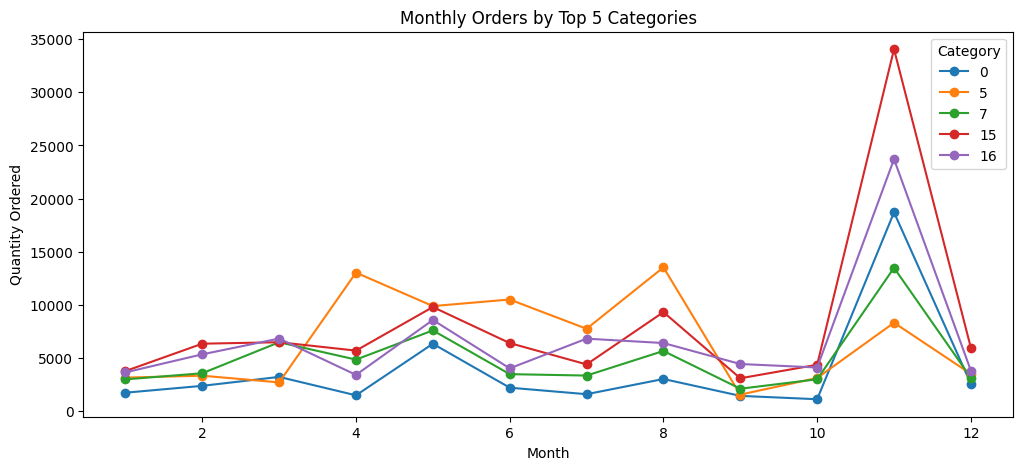

In [46]:
# line chart shows which categories are ordered more in which months
pivot = df_top.pivot(index='Month', columns='category_name_1', values='qty_ordered')
pivot.plot(marker='o', figsize=(12, 5))
plt.title('Monthly Orders by Top 5 Categories')
plt.xlabel('Month')
plt.ylabel('Quantity Ordered')
plt.legend(title='Category')
plt.show()

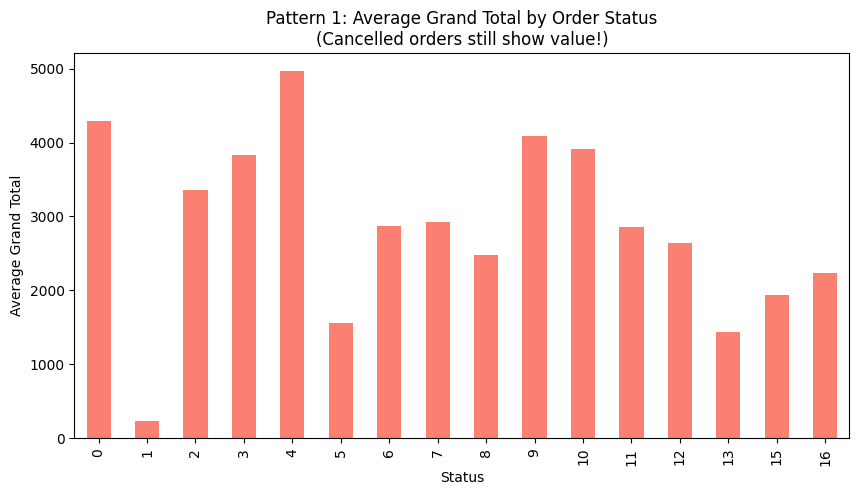

In [47]:
# hidden patterns that are counter-intuitive for a layman
# hidden pattern 1
# Cancelled orders still have a grand_total value
# counter-intuitive because you would expect cancelled orders to have 0 revenue
avg_by_status = df.groupby('status')['grand_total'].mean()
plt.figure(figsize=(10, 5))
avg_by_status.plot(kind='bar', color='salmon')
plt.title('Pattern 1: Average Grand Total by Order Status\n(Cancelled orders still show value!)')
plt.xlabel('Status')
plt.ylabel('Average Grand Total')
plt.show()

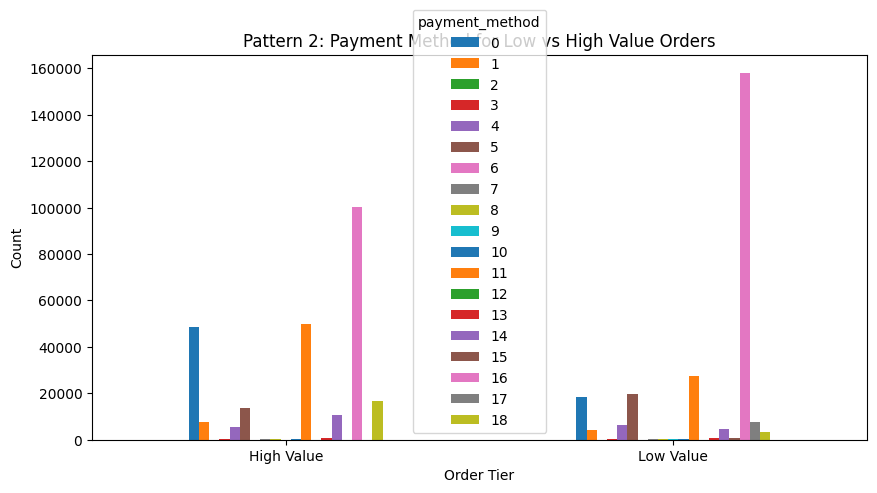

In [48]:
# hidden pattern 2
# COD is used even for high value orders
# counter-intuitive because expensive orders are expected to use digital payments
median_val = df['grand_total'].median()
df['order_tier'] = df['grand_total'].apply(lambda x: 'High Value' if x >= median_val else 'Low Value')

pd.crosstab(df['order_tier'], df['payment_method']).plot(kind='bar', figsize=(10, 5))
plt.title('Pattern 2: Payment Method for Low vs High Value Orders')
plt.ylabel('Count')
plt.xlabel('Order Tier')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_1226/2116406068.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_orders.index, y=monthly_orders.values, palette='viridis')


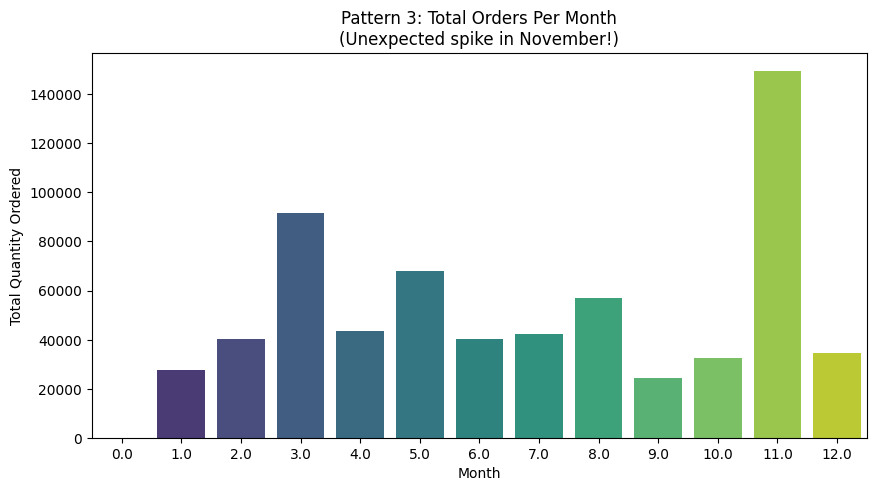

In [49]:
# hidden pattern 3
# November has a huge spike in orders across all categories
# counter-intuitive because Pakistan does not celebrate Christmas
# the spike is likely due to local sales events
monthly_orders = df.groupby('Month')['qty_ordered'].sum()
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_orders.index, y=monthly_orders.values, palette='viridis')
plt.title('Pattern 3: Total Orders Per Month\n(Unexpected spike in November!)')
plt.xlabel('Month')
plt.ylabel('Total Quantity Ordered')
plt.show()

In [58]:
df.to_csv('preprocessed_ecommerce.csv', index=False)
